# 학습내용

마지막 챕터입니다.

지금까지 LoRA / QLoRA에 대해 살펴보고, 양자화된 4bit 모델에 Finetuning (QLoRA)까지 해보았습니다.

이번 챕터에서는 다음과 같은 내용을 다룹니다.

1. 추론기 소개
    - Pytorch에서 모델 추론
    - llama.cpp
    - vllm

2. 양자화된 모델의 성능 평가
    - llama.cpp를 사용한 성능평가
    - 추론속도(tps) / 답변품질

3. 직접 양자화 해보기
    - llama.cpp를 사용하여, 양자화 모델 만들기

# 1. 추론기(Inference Engine) 이해

### 추론기 소개

학습된 LLM을 실제 서비스를 할 때는, 빠른 속도로 추론이 되어야만 합니다!

추론에 어떤 프로그램을 쓰느냐에 따라서 추론 성능이 크게 차이가 발생하는데요.

추론기는 이렇게 비유할 수 있습니다.

 - LLM = 게임 소프트웨어
 - 추론기는 "게임기"

좋은 게임기를 쓰면 게임이 시원 시원하게 동작되는 것으로 비유할 수 있겠습니다~.

### 추론기의 두 가지 타입

추론기는 두 가지 타입으로 분류할 수 있습니다.

1. **학습 / 연구 / 실험용**
   1) PyTorch 자체
   2) 허깅페이스의 Transformer Library
       - Unsloth에서도 이 Library를 사용합니다.
       - 그 동안 이 Library를 써서 추론을 해왔습니다~!
         
2. **실제 추론 서비스용**
   - **llama.cpp**
   - vllm


학습 및 연구용은 고성능이 필요하지 않습니다!

실제 서비스에서는 추론속도가 빨라야 더 많은 고객이 AI 서비스를 원활하게 사용할 수 있습니다.

### 이번 수업에서 다룰 추론기 : llama.cpp 소개

이번 수업에서는 llama.cpp를 주력 추론기로 사용할 겁니다!

llama.cpp는 C / C++로 만들어진 Local모델 고성능 추론기(Inference Engine) 입니다.

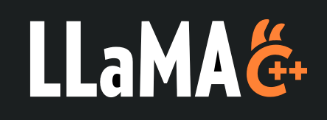

허깅페이스의 Transformer나 Unsloth로 추론을 해서 성능테스트를 하면, 정확한 성능 비교가 쉽지 않습니다. (오차율이 조금 커요)

이번 수업의 목적은 **"양자화 성능비교"** 입니다. 정확히 비교를 위해서는 llama.cpp 또는 vllm을 써야합니다.

특히 llama.cpp는 모델을 **"양자화 변환"** 하는 기능까지 포함되어 있어서~~ llama.cpp를 사용해서 수업을 진행하겠습니다.

### llama.cpp 많이 쓰나요?
- 고성능 추론기 중 가장 인기가 많은 추론기입니다.
    - ollama에서도 llama.cpp를 사용합니다.
- 한번 허깅페이스로 가볼게요!
  - 인기가 엄청 많은 LLama3.1 모델 링크입니다.
      - https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct
  - 여기서 아래 버튼을 눌러보세요

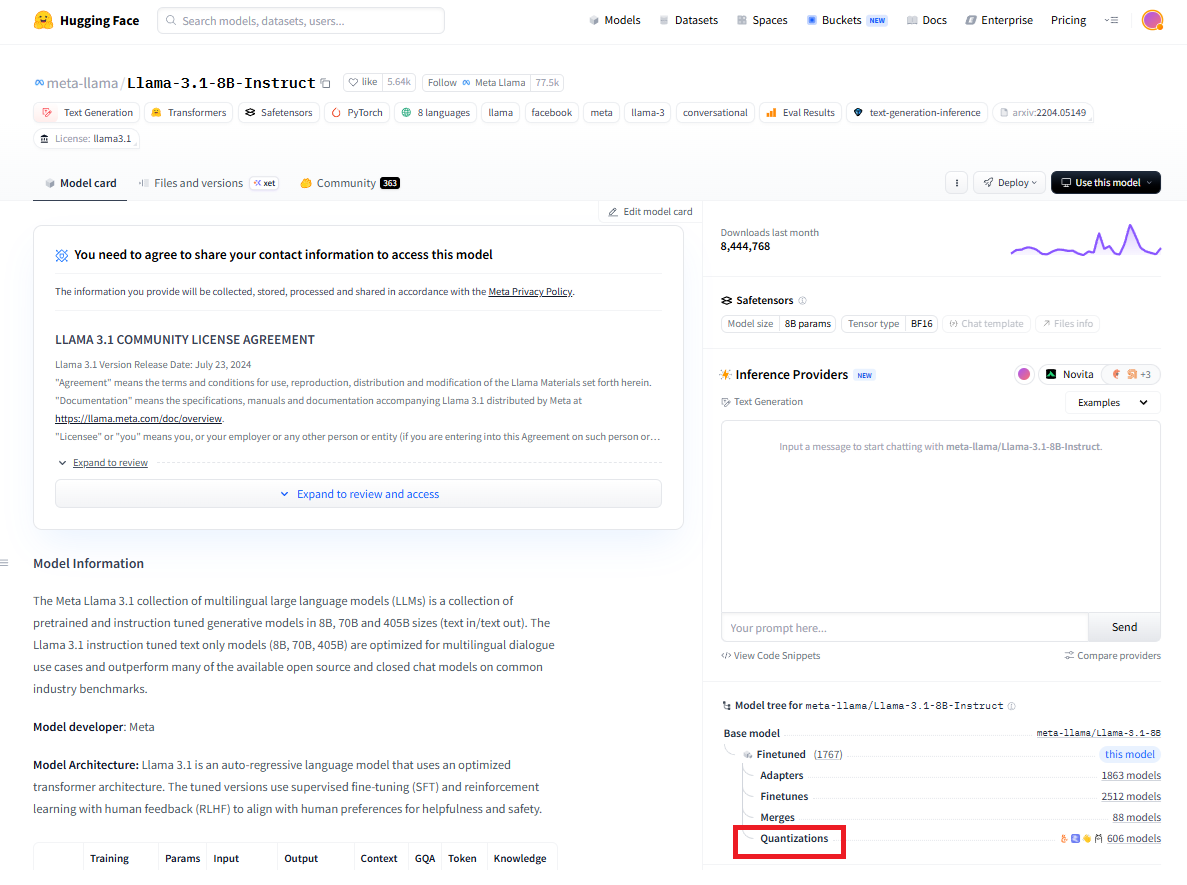

여기서 GGUF 라고 써있는 파일들이 전부 llama.cpp 용 모델입니다.

아래 모델 말고 qwen 모델 등 다른 모델들을 살펴보아도 GGUF포맷이 많은 것을 보아, llama.cpp의 인기를 실감할 수 있습니다.

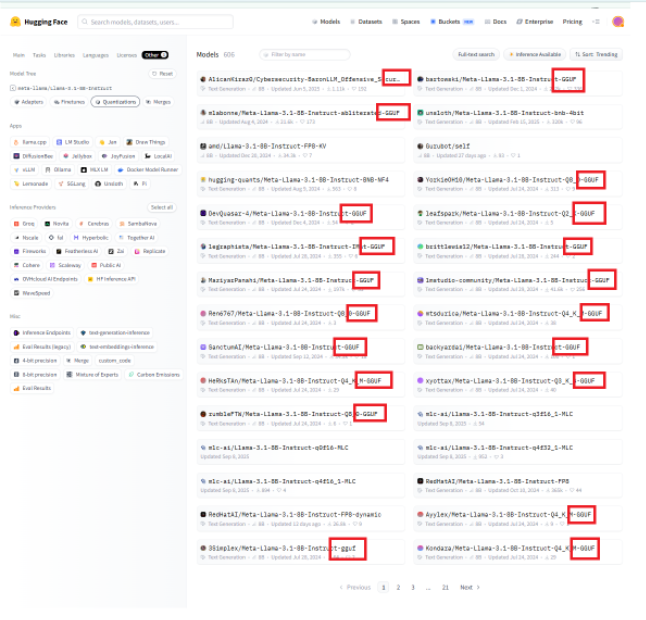

특히 llama.cpp는 로컬 Model 고성능 추론기로 가장 인기가 많습니다.

참고로 실제 회사에서 모델 서비스할 때는 llama.cpp 보다 vllm이 인기가 더 많습니다.
  - 병렬 추론 성능과 최적화가 잘 되어있습니다.

# 2. GGUF 포맷

### GGUF 포맷이란?

llama.cpp에서 사용하는 LLM 전용 포맷입니다.

원래 PyTorch로 학습한 모델은 .safetensors 또는 .pt 입니다.

이 모델을 더 빠른 속도로 추론시키기 위해 최적화 + (옵션 : 양자화) 까지 하여 변환한 것이 gguf 파일입니다.

### 모델 변환의 필요성 이해

- llama.cpp를 아주 간단히 소개드렸고, 이제 **왜 모델 변환이 필요한지 천천히 살펴봅시다.**

- 이전 수업에서 허깅페이스에 업로드된 모델을 다운로드 받아서 로드 했습니다.
  - .safetensors 라는 파일을 다운로드 받았었죠.
  - PyTorch가 사용하는 확장자입니다.

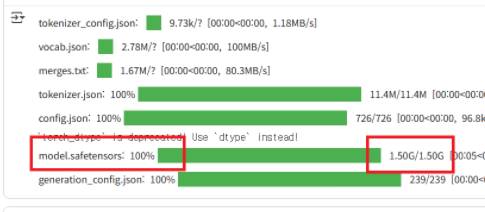

- llama.cpp 라이브러리는 PyTorch용 모델을 (.safetensor)를 지원하지 않습니다.
  - GGUF포맷 파일인 '.gguf' 파일로된 모델만 지원합니다. 흑흑
 
- 내가 만든 모델을 llama.cpp 로 추론시키려면 **반드시 GGUF로 변환**해야 합니다.

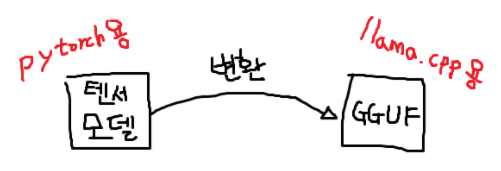

- 여기까지 모델을 변환해야하는 이유였습니다.

### [참고] GGUF에 대한 이야기

- llama.cpp에서는 GGUF 포맷만을 지원합니다
  - 이 Library는 PyTorch 모델을 지원하지 않습니다.
  - 고성능 추론을 위해 GGUF 포맷의 모델로 변환을 할 수 밖에 없습니다.

- GGUF 라는 이름은 개발자의 이름을 따서 만들었습니다.
  - llama.cpp 라이브러리 개발자 이름은 Georgi Gerganov (조지 거가노브, 줄여서 GG) 입니다.
  - 그리고 GGUF의 약어는 Georgi Gerganov Unified Format 이죠. (저는 고기육포 파일 이라고 부릅니다.)

- 이 GGUF 포맷을 따르는 파일은 .gguf 확장자를 갖습니다.
- 이 파일에는 다음과 같은 정보가 다~ 들어있습니다.
  - 텐서 파일 (Weight값)
  - Vocab
  - Model 메타정보
  - (양자화를 했다면, 양자화 정보)
  - 등등

- 이 파일 하나만 있으면 tokenizer, config 등 이런 파일들이 필요없어요.

### 실습 모델 : Qwen2.5 - 1.5B 모델

2개의 모델로 실습할 것입니다.

실습 모델1 : Qwen2.5 (1.5B 모델)
 - https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct
 - 이 모델은 양자화가 안된 16bit 모델입니다.

실습 모델2 : Qwen2.5 (1.5B 모델) - GUFF로 변환
 - 실습 모델 1번을 GUFF로 변환한 모델들이 들어어있습니다.
 - https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct-GGUF
 

아래 링크를 누른 후, Files and version으로 들어가봅시다. (GUFF 파일)
- https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct-GGUF

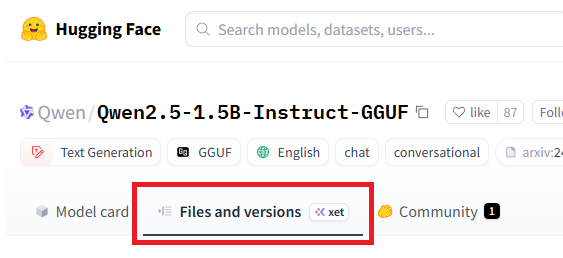

아래 이미지를 보면 파일이 많습니다.
  - 이건 종류별로 하나씩 다 만든겁니다.
  - 아메리카노, 라떼, 프라페치노... 각각 동작되는 모델입니다.
  - **.gguf 파일 하나만 있으면 추론이 잘 됩니다.**

파일 설명
  - BF16 : 양자화 없는 원본입니다.
  - IQ : 더 정밀하고 손실이 적은 4bit 양자화
  - Q2, Q3, Q4, Q6.. = 양자화 bit 수
  - 그 뒤에 옵션은 양자화 세부 옵션들 (K_L, K_M, K_S)

이중에서 뭘 쓸까요?
  - llama.cpp 라이브러리가 가장 권장 권장하는 옵션은 **Q4_K_M** 입니다. 이걸 사용하면 됩니다.
  - 그리고 비교를 위해 **FP16.gguf**도 사용할 것입니다.
  
  

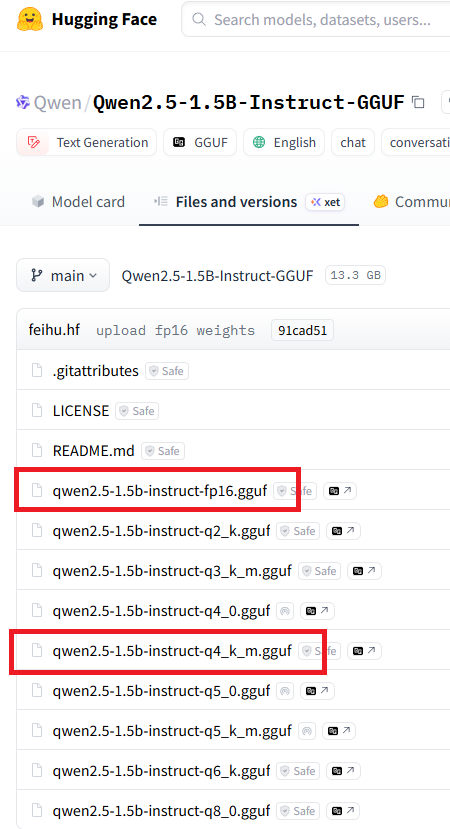

# 3. 양자화된 모델 vs 양자화 안한 모델 성능 테스트

GGUF 파일 추론 테스트 후, 양자화 전 후 모델의 성능을 비교해봅시다.


### GGUF 파일 추론 테스트
- llama.cpp 라이브러리를 사용하여 추론을 해봅시다.
- C++ Library의 Python 래퍼 가 있습니다.
  - llama-cpp-python 입니다.
    - 아래 설치 명령어는 **GPU 옵션이 켜있는 패키지**를 다운 받는 명령어입니다.
    - CUDA 12.1 버전은 CUDA 12.4 이상의 버전 모두 호환이 잘 됩니다.

In [1]:
# %%capture
# !pip uninstall llama-cpp-python -y
!pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu121
# !pip install --no-cache-dir llama-cpp-python==0.2.77 --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu124
!pip install huggingface_hub
# !pip show llama-cpp-python

Looking in indexes: https://pypi.org/simple, https://abetlen.github.io/llama-cpp-python/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 GB 14.3 MB/s  0:01:39m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [llama-cpp-python][llama-cpp-python]


- 이후 GGUF 모델을 다운로드합니다.
- [참고] 허깅페이스 키 (HF_TOKEN=hf_...)를 .env에 추가를 해두면 다운로드 속도가 더 빨라진다고 안내되고 있습니다.

In [4]:
# [옵션] 허깅페이스 키를 .env에 등록 후에 아래 코드를 실행해주세요.

from dotenv import load_dotenv
load_dotenv() # .env파일에서 환경설정 가져오기

True

In [5]:
from huggingface_hub import hf_hub_download

# 양자화 안된 모델
model_path1 = hf_hub_download(
    repo_id="Qwen/Qwen2.5-1.5B-Instruct-GGUF",    
    filename="qwen2.5-1.5b-instruct-fp16.gguf"
)
print("모델1 다운로드 완료:", model_path1)

# 양자화 된 모델
model_path2 = hf_hub_download(
    repo_id="Qwen/Qwen2.5-1.5B-Instruct-GGUF",    
    filename="qwen2.5-1.5b-instruct-q4_k_m.gguf"
)
print("모델2 다운로드 완료:", model_path2)

qwen2.5-1.5b-instruct-fp16.gguf:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

모델1 다운로드 완료: /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct-GGUF/snapshots/91cad51170dc346986eccefdc2dd33a9da36ead9/qwen2.5-1.5b-instruct-fp16.gguf


qwen2.5-1.5b-instruct-q4_k_m.gguf:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

모델2 다운로드 완료: /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct-GGUF/snapshots/91cad51170dc346986eccefdc2dd33a9da36ead9/qwen2.5-1.5b-instruct-q4_k_m.gguf


- 모델을 로드합니다.

In [6]:
from llama_cpp import Llama

# 양자화 안된 모델
llm1 = Llama(
    model_path=model_path1, # 다운로드한 GGUF 파일 경로
    n_gpu_layers=-1, # -1 : gpu에 모든 Layer 로드
    verbose=False, # 추론시 로그 출력 OFF
)

# 양자화 된 모델
llm2 = Llama(
    model_path=model_path2, # 다운로드한 GGUF 파일 경로
    n_gpu_layers=-1, # -1 : gpu에 모든 Layer 로드
    verbose=False, # 추론시 로그 출력 OFF
)

llama_context: n_ctx_seq (512) < n_ctx_train (8192) -- the full capacity of the model will not be utilized
llama_context: n_ctx_seq (512) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


추론 시작!

In [7]:
import time, re

# ===== stream 수집 함수 (토큰 수 계산) =====
def stream_generate(llm, prompt):
    tokens = []
    token_count = 0

    for chunk in llm(prompt, max_tokens=512, temperature=0.7, stream=True):
        token = chunk["choices"][0]["text"]

        tokens.append(token)
        token_count += 1

    return tokens, token_count


# ===== invoke =====
def invoke(llm, prompt):
    
    start = time.time() # 측정 시작
    tokens, token_count = stream_generate(llm, prompt)
    elapsed = time.time() - start # 측정 종료

    # 결과 Text 생성
    txt = "".join(tokens)
    
    return txt, elapsed, token_count
    
# ===== 벤치마크 함수 =====
def run_benchmark(llm, prompt, limit_tokens=1000):
    acc_elapsed = 0.0
    acc_tokens = 0

    # 첫 로딩은 측정 안함
    invoke(llm, prompt)
    
    while True:
        txt, elapsed, num_tokens = invoke(llm, prompt)

        acc_elapsed += elapsed
        acc_tokens += num_tokens

        print(f"AI : {txt}")
        print(f"추론시간 : ⏱ {elapsed:.2f}s")        
        print(f"누적 토큰 수: {acc_tokens} / {limit_tokens}")
        print()

        if acc_tokens > limit_tokens:
            break

    tps = acc_tokens / acc_elapsed if acc_elapsed > 0 else 0

    return tps


# ===== Qwen 전용 프롬프트 ====
def qwen_prompt(user_text, system_text):
    return f"<|im_start|>system\n{system_text}<|im_end|>\n<|im_start|>user\n{user_text}<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n"


prompt = qwen_prompt("좋아하는 음식과 특징을 말해줘", "짧게 단답형으로 대답해")

tps1 = run_benchmark(llm1, prompt) # 양자화가 안된 모델
tps2 = run_benchmark(llm2, prompt) # 양자화가 된 모델

print()
print("====================")
print("📊 Benchmark 결과")
print("====================")

print(f"양자화가 안된 모델 (FP16, llama.cpp)")
print(f"  - 초당 토큰 생성량: {tps1:.2f} t/s")
print()

print(f"4bit 양자화가 된 모델 (llama.cpp)")
print(f"  - 초당 토큰 생성량: {tps2:.2f} t/s")
print()

AI : 알아서 알려드릴게요.  
당신에게 가장 좋아하는 음식과 그 음식의 특징을 말씀해주세요.
추론시간 : ⏱ 0.18s
누적 토큰 수: 31 / 1000

AI : <br>

나는 AI로 인해서 음식을 좋아하는 것이 아니라 정보를 제공하고 돕는 역할을 합니다. 하지만, 일반적으로 한국인들은 다양한 음식에 좋아하는 경우가 많습니다. 예를 들어, 만두, 볶음밥, 갈비탕, 불고기 등이 대표적인 음식들입니다. 각각 다른 지역의 음식이나 맛에 따라 다양한口味가 있습니다.

</br>

<br>

하지만, 저는 음식에 대해 직접적으로 좋아하는 것은 아닙니다. 음식에 대해 자세히 알고 싶다면, 직접적인 정보를 제공할 수 있도록 도와드리겠습니다.
추론시간 : ⏱ 0.80s
누적 토큰 수: 166 / 1000

AI : <br>

음식: 샐러드<br>
특징: 신선한 향과 맛이 특징입니다. 다양한 샐러드로 선택이 가능합니다.
추론시간 : ⏱ 0.21s
누적 토큰 수: 201 / 1000

AI : 좋아하는 음식은 고기와 채소를 섞은 조림밥입니다. 맛과 향이 복잡하고, 건강한 식단으로 인식됩니다. 주로 참치, 오징어, 돼지 등을 사용합니다.

</think>
추론시간 : ⏱ 0.35s
누적 토큰 수: 257 / 1000

AI : <br>저는 인공지능으로서 개인적인 식 tastes를 가지고 있지 않아요. 하지만 일반적으로 인공지능이 좋아하는 음식은 다양한 종류의 음식을 좋아하고 다양한 맛이 있는 음식을 선호합니다. 또한, 음식의 재료, 구조, 맛, 조리법 등에 대한 정보를 제공하거나 추천하는 것이 저의 역할입니다.
추론시간 : ⏱ 0.53s
누적 토큰 수: 345 / 1000

AI : 나는 인공지능으로서 개인적인 선호도나 음식에 대한 정보를 가지고 있지 않습니다. 하지만 다양한 음식을 즐기는 많은 사람들의 인기있는 음식들을 소개해드릴 수 있습니다. 예를 들어, 패스트푸드에서의 피자, 스파이크볼, 치킨, 피자, 케이크 등이 있습니다. 

또한, 다양한 음식에 대한 정보를 제공

### 추론 처리 속도 단위 : tps

- tps는 token per second로 초당 몇 토큰을 생성해내는지를 나타냅니다.

- 한 Token은 영어 단어 하나 / 한글 한글자 수준입니다.

- 이를 이렇게 이해해주시면 되겠습니다.
   - LLM의 타이핑 속도
   - 한글을 출력하는데 200 t/s 라면 초당 200타를 쓴다. 라는 의미로 쉽게 감을 잡을 수 있습니다.
   - (영타는 정확하지 않지만, 약 600타 정도 되겠죠?)

### 메모리 측정 방법

- llama.cpp가 추론시 사용하는 메모리를 측정하려면 llama.cpp 공식 벤치마크 도구를 따로 사용하는 방법이 있으나, 이 수업에서 다루진 않습니다.

### 답변 품질 측정 방법

LLM-as-a-Judge로 답변 품질을 측정합니다.
- Upstage API Key로 테스트합니다.

먼저 API Key 세팅을 점검합니다.

In [8]:
import os
from openai import OpenAI

from dotenv import load_dotenv
load_dotenv() # .env파일에서 환경설정 가져오기

# Upstage API
llm = OpenAI(api_key=os.getenv("UPSTAGE_API_KEY"), base_url="https://api.upstage.ai/v1")

model = "solar-pro3"
prompt="KFC 버거 추천좀 해줘, 짧게 두줄로 요약해"

response = llm.chat.completions.create(model=model, messages=[{"role": "user", "content": prompt}])
print(response.choices[0].message.content)

KFC 대표 버거: **치킨필 A. 와일드 웨스턴**, 바삭한 닭가슴살에 매콤한 소스가 일품이에요.  
버거 추천: **치킨버거**와 **징거버거** 중 취향 따라 골라 보세요!


이제 각 답변에 대해 답변 품질까지 확인합니다.

1 ~ 10점으로 한글 문법에 맞게 잘 작성되었는지 (1 ~ 5점), 질문에 대한 대답이 맞는지? (1 ~ 5점) 합산 10점으로 답변 품질을 측정합니다.


In [10]:
import json
import os
from openai import OpenAI


# ===== Upstage 평가 모델 =====
llm_eval = OpenAI(
    api_key=os.getenv("UPSTAGE_API_KEY"),
    base_url="https://api.upstage.ai/v1"
)
eval_model = "solar-pro3"


# ===== 일반 추론 =====
def generate_answer(llm, prompt):
    response = llm(prompt, max_tokens=512, temperature=0.7)
    return response["choices"][0]["text"].strip()


# ===== 평가 =====
def evaluate_answer(question, answer):
    system_prompt = """
너는 답변 평가자다.

다음 기준으로 0~6점 평가하라.

1. 한글 작성 능력 (0~3점)
 - 한국인이 알아볼 수 없는 글이라면 0점
 - 전체 한글로 잘 이뤄져있다면 3점 (일부 markdown, br 태그가 있어도 된다.)
2. 질문에 대한 대답의 적합성 (0~3점)
 - 사람이 이해할 수 없는 문장이라면 0점
 - 질문과 전혀 관련성이 없는 Text라면 1점
 - 질문에 대한 답변을 했지만 관련없는 내용이 섞여있다면 2점
 - 긍정 or 부정 or 의문 등으로 질문에 대한 자연스러운 대답을 했다면 3점

총점 = 두 점수 합산

반드시 JSON 형식으로 출력하라.

{
  "grammar_score": int,
  "relevance_score": int,
  "total_score": int,
  "feedback": "간단한 평가"
}
"""

    user_prompt = f"""
[질문]
{question}

[답변]
{answer}
"""

    response = llm_eval.chat.completions.create(
        model=eval_model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]
    )

    return response.choices[0].message.content


# ===== JSON 파싱 =====
def parse_score(eval_text):
    try:
        return json.loads(eval_text)
    except:
        return {"total_score": 0}


# ===== 품질 평가 루프 =====
def run_quality_eval(llm, prompt, question, num_runs=5):
    scores = []

    for i in range(num_runs):
        print(f"\n=== 실행 {i+1} ===")

        # 일반 추론
        answer = generate_answer(llm, prompt)
        print(f"AI : {answer}")

        # 평가
        eval_text = evaluate_answer(question, answer)
        print(f"🧠 평가 결과: {eval_text}")

        parsed = parse_score(eval_text)
        scores.append(parsed.get("total_score", 0))

    avg = sum(scores) / len(scores) if scores else 0

    return avg, scores


# ===== Qwen 프롬프트 =====
def qwen_prompt(user_text, system_text):
    return f"<|im_start|>system\n{system_text}<|im_end|>\n<|im_start|>user\n{user_text}<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n"


# ===== 실행 =====
question = "8살 아이에게 뿡, 방구 라는 말만 해도 깔깔깔깔 웃는다. 왜 그럴까?"
prompt = qwen_prompt(question, "20글자 이내, 한 문장으로 대답해")

avg1, scores1 = run_quality_eval(llm1, prompt, question) # 양자화 안한 모델
avg2, scores2 = run_quality_eval(llm2, prompt, question) # 양자화 한 모델


# ===== 결과 출력 =====
print("\n====================")
print("📊 품질 평가 결과")
print("====================")

print("FP16 모델")
print(f"  - 평균 점수: {avg1:.2f}")
print(f"  - 점수 리스트: {scores1}")
print()

print("4bit 양자화 모델")
print(f"  - 평균 점수: {avg2:.2f}")
print(f"  - 점수 리스트: {scores2}")
print()


=== 실행 1 ===
AI : 방구는 상징적인 용어로, 아이들을 위한 친근한 표현이므로 웃음을 provokes.
🧠 평가 결과: {
  "grammar_score": 2,
  "relevance_score": 2,
  "total_score": 4,
  "feedback": "답변에 영어 단어(provokes)가 포함되어 있어 한글 작성 능력이 부분적으로 감점되었습니다. 답변 내용은 질문과 관련이 있지만, 설명이 부족하고 전문 용어가 사용되어 8살 아이의 웃음 유발 이유를 충분히 설명하지 못했습니다."
}

=== 실행 2 ===
AI : 8살 아이는 방구를 좋아하고, 이는 그의 안색이나 행동으로 인해 알 수 있다. 방구는 아이에게 신선함과 흥미를 줘, 이는 그를 웃게 만드는 이유이다.

</think>
🧠 평가 결과: {
  "grammar_score": 2,
  "relevance_score": 2,
  "total_score": 4,
  "feedback": "한글 작성 능력이 약간 부족하며(문법적 오류 및 어색한 표현), 답변의 적합성은 보통입니다. '안색이나 행동' 등 관련 없는 내용이 포함되었고, 8살 아이의 발달 단계나 심리적 특성(유아적 유머, 사회적 유대감 등)이 고려되지 않아 설명이 부족합니다."
}

=== 실행 3 ===
AI : 이 아이는 방구역에서 충분한 경험을 갖고, 이를 통해 방구라는 표현이 재미있게 인식하고 웃는 것 같습니다.
🧠 평가 결과: {
  "grammar_score": 2,
  "relevance_score": 2,
  "total_score": 4,
  "feedback": "답변은 대체로 한글로 작성되었으나, '방구역'과 같은 비표현적 단어 사용으로 자연스러움이 떨어집니다. 질문에 대한 답변으로 방구가 재미있다는 점은 언급했으나, 8살 아이의 발달 단계나 심리적 특성(예: 신체 기능에 대한 호기심, 유머 감각 발달 등)을 고려한 설명이 부족해 관련성이 부분적으로만 충족됩니다."
}

=== 실행 4 ===
AI 

답변 품질 테스트를 할 때는 더 많은 질문과 답변 예시 기반으로 성능측정을 해야하지만

간단하게 LLM-as-a-judge로 답변 품질 결과를 살펴보았습니다.

### [참고] 추론기 성능 비교 - llama.cpp vs 허깅페이스의 Transformer 라이브러리

- 항상 써오던 허깅페이스 Transformer Library (Unsloth와 동일)가 llama.cpp에 비해 어느정도 추론 성능차이가 나는지 살펴봅시다.
  - 같은 모델, 같은 방식으로 성능측정을 합니다.
  - 결론 : llama.cpp가 역시 빠릅니다.

In [11]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

# 모델 로드
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16, #BF16
    device_map="auto"
)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.7.0+cu128).


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [12]:
import time
import threading
from transformers import TextIteratorStreamer


def invoke(model_inputs):
    streamer = TextIteratorStreamer(
        tokenizer,
        skip_prompt=True,
        skip_special_tokens=True
    )

    tokens = []
    token_count = 0

    # 시간측정 전 Streamming을 위한 Thread 생성
    thread = threading.Thread(
        target=model.generate,
        kwargs=dict(
            **model_inputs,
            max_new_tokens=512,
            streamer=streamer
        )
    )
    thread.start()

    start = time.time() # 측정 시작
    for token in streamer:
        tokens.append(token)
        token_count += 1
    elapsed = time.time() - start if start else 0 #측정 종료

    thread.join()

    result = "".join(tokens)

    return result, elapsed, token_count


# ===== Benchmark =====
def run_benchmark(model_inputs, limit_tokens=1000):
    acc_elapsed = 0.0
    acc_tokens = 0

    # 초기 로딩 제외
    invoke(model_inputs)

    while True:
        result, elapsed, num_tokens = invoke(model_inputs)

        acc_elapsed += elapsed
        acc_tokens += num_tokens

        print(f"AI : {result}")
        print(f"추론시간(토큰 생성 기준) : ⏱ {elapsed:.2f}s")
        print(f"누적 토큰 수: {acc_tokens} / {limit_tokens}")
        print()

        if acc_tokens > limit_tokens:
            break

    tps = acc_tokens / acc_elapsed if acc_elapsed > 0 else 0
    return tps


# ===== Prompt 구성 =====
def build_prompt(user_text, system_text):
    messages = [
        {"role": "system", "content": system_text},
        {"role": "user", "content": user_text}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    return tokenizer([text], return_tensors="pt").to(model.device)


# ===== 실행 =====
user_text = "좋아하는 음식과 특징을 말해줘"
system_text = "짧게 단답형으로 대답해"

model_inputs = build_prompt(user_text, system_text)
tps = run_benchmark(model_inputs)

print()
print("====================")
print("📊 Benchmark 결과")
print("====================")

print(f"양자화 안된 모델 (16bit 모델, 허깅페이스의 Transformer 추론기 사용)")
print(f"  - 초당 토큰 생성량: {tps:.2f} t/s")
print()

AI : 제가 인공지능이기 때문에 개인적인 식 tastes나 취향은 가지고 있지 않습니다. 하지만 일반적으로 사람들 중 많은 사람들이 좋아하는 음식들을 찾아볼 수 있습니다. 예를 들어, 피자, 샐러드, 치킨,咖喱料理, 떡볶이 등 다양한 음식들이 있습니다. 선택된 음식의 특징에 대해 더 알고 싶으시다면 말씀해 주세요!
추론시간(토큰 생성 기준) : ⏱ 3.43s
누적 토큰 수: 97 / 1000

AI : 죄송합니다, 저는 인공지능이기 때문에 개인적인 식 tastes나 선호를 가질 수 없습니다. 하지만 다양한 종류의 음식들이 좋아하고, 각각의 음식에는 그 자체의 맛과 재미가 있습니다.
추론시간(토큰 생성 기준) : ⏱ 2.04s
누적 토큰 수: 155 / 1000

AI : 제가 인공지능이기 때문에 식사를 즐기는 능력이 없어요. 하지만, 다양한 음식 종류를 알고 있어요! 주방에서 가장 좋아하는 음식은 피자입니다. 그 이유는 맛있고 직업적인 조리법 때문이라고 생각해요.
추론시간(토큰 생성 기준) : ⏱ 2.43s
누적 토큰 수: 225 / 1000

AI : 죄송합니다, 저는 인공지능이기 때문에 개인적인 선호도나 식단에 대해 알 수 없습니다. 하지만 여러분에게 가장 좋은 음식 추천은 바로 그 사람들의 취향에 따라 달라집니다.
추론시간(토큰 생성 기준) : ⏱ 1.90s
누적 토큰 수: 279 / 1000

AI : 제가 인공지능이기 때문에 개인적인 식단은 없습니다. 하지만, 일반적으로 많은 사람들이 좋아하는 음식들 중에서 주요한 종류는 다음과 같습니다:

1. 치킨: 세계적으로 가장 많이 즐기는 음식 중 하나로, 다양한 스타일의 요리가 있습니다.
2. 피자: 특히 미국과 유럽에서 인기가 많습니다.
3. 샐러드: 건강에 좋은 레시피로 사랑받고 있습니다.
4. 패스트푸드: 빠르고 간편하게 먹을 수 있는 음식입니다.
5. 파스타: 전통적인 이탈리안 음식 중 하나로도 인기가 있습니다.

이 외에도 다양한 지역의 음식들이 각자의 특징과 맛을 가지고 있습니다.
추론시간(토큰

### 실험 결과

- GGUF가 확실히 빠르게 토큰을 생성해냅니다.
- 추론 안정성도 차이가 있었습니다.
  - 모델에 따라 다르지만 GGUF는 한번에 결과가 잘 나오는데, PyTorch는 간헐적으로 무한루프에 빠지곤 했습니다.
- 역시 배포는 GGUF로 해야되겠습니다.
- 아래 성능 측정은 코랩으로 측정한 결과입니다. 참고하세요

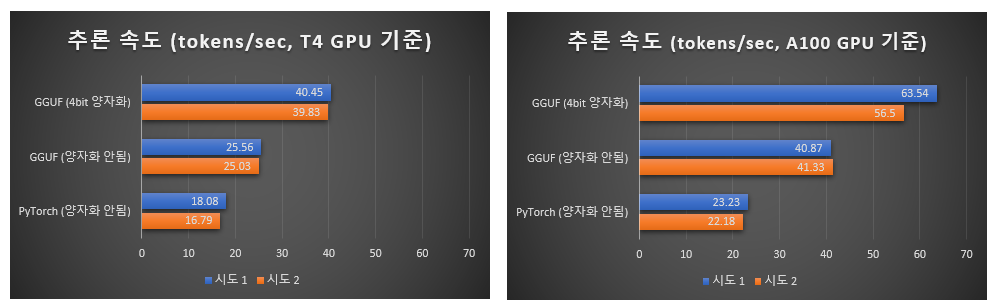

# 4. GGUF 모델 변환하기


### 커널 재부팅

앞서 실습을 진행하면서 GPU vram이 부족하여 에러가 발생될 수 있습니다.

이번 실습을 진행하기 전, 쥬피터노트북 커널을 재시작 한 후에 진행해주세요.

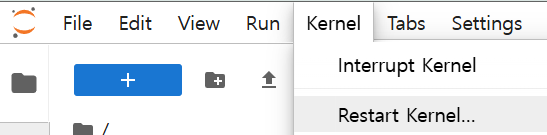

이후 llama-cpp-python을 다시 설치해주면 됩니다.

In [12]:
%%capture
!pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu121
!pip install huggingface_hub

### 변환할 모델 준비

- 이번 챕터에서는 PyTorch 모델을 직접 GGUF로 변환 후 추론까지 해보겠습니다.
- 먼저 모델을 로드 후, 파일로 저장하겠습니다.

In [13]:
# 모델 저장
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

# 모델 다운로드 & 로드
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)


# 이후 파인튜닝을 다 했다고 가정합니다.
# 파인튜닝 코드 시작
# ...~
# 파인튜닝 코드 끝


# 파인튜닝 완료된 모델 저장 (5분 소요)
print('모델 저장중...')
save_path = "./my_trained_model"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("모델 저장 완료:", save_path)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

모델 저장중...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

모델 저장 완료: ./my_trained_model


- 저장이 잘 된것을 확인할 수 있습니다.

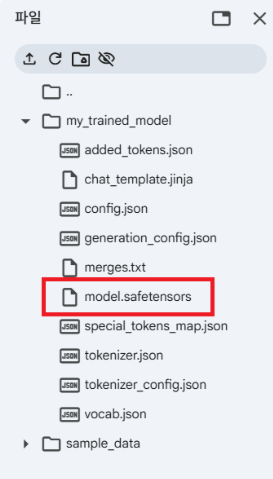

### GGUF 포맷으로 변환

- 이제 .safetensors --> GGUF로 변환을 해야하는데 두 가지 방법이 있습니다.

- 방법1 : llama.cpp 공식 가이드
  1. `git clone https://github.com/ggerganov/llama.cpp` 을 Clone 하고
  2. convert_hf_to_gguf.py로 GGUF 변환 (BF16)을 하고
  3. 빌드하고 (cmake)
  4. llama-quantize 툴로 4bit 양자화를 한다.

<br/>

- **방법2 : Unsloth 함수 호출**
  1. save_pretrained_gguf() 함수를 호출한다.
      - 내부적으로 위 동작을 수행합니다.
  2. 끝!

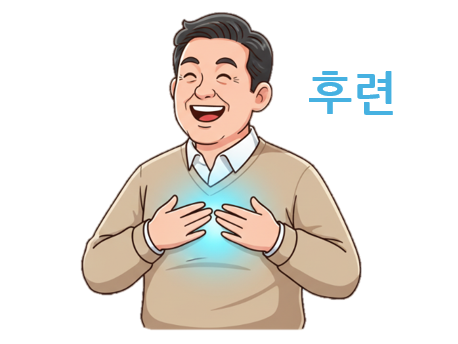

- unsloth 를 설치합시다.
  - unsloth에서 safetensors --> gguf 파일로 변환만 할것이라, 아래 pip install로 충분합니다.

In [14]:
!pip install -qU unsloth

변환에 필요한 의존성 파일을 추가로 설치해줍시다.

In [15]:
!apt-get update -q
!apt-get install -q -y build-essential make cmake libssl-dev libcurl4-openssl-dev

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy InRelease [270 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1309 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy/restricted amd64 Packages [164 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3842 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy/main amd64 Packages [1792 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6803 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy/universe amd64 Packages [17.5 MB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [62.6 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy/multiverse amd64 Packages [266 kB]
Get:13 http://archive.ubuntu.com/ubuntu jam

- 변환합니다!
  - 아래 코드를 실행하면, 16분 정도 걸린다고 로그 메세지가 나옵니다.

In [16]:
from unsloth import FastLanguageModel

# 기존 저장된 모델 경로
model_path = "./my_trained_model"

# GGUF 변환 (오래걸림)
model, tokenizer = FastLanguageModel.from_pretrained(model_path, dtype = None)

# 양자화 후 저장
model.save_pretrained_gguf(
    model_path,
    tokenizer = tokenizer,
    quantization_method = "q4_k_m",
)

print('변환 완료!')

/tmp/ipykernel_20/1495885337.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.18: Fast Qwen2 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA GeForce RTX 3080 Ti. Num GPUs = 1. Max memory: 12.0 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Unsloth: Model is not a PEFT model. Using existing checkpoint at ./my_trained_model
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


[unsloth_zoo.llama_cpp|WARNING]Unsloth: Qwen2MoE num_experts patch target not found.


Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['./my_trained_model_gguf/my_trained_model.BF16.gguf']
Unsloth: [2] Converting GGUF bf16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['./my_trained_model_gguf/my_trained_model.Q4_K_M.gguf']
Unsloth: No Ollama template mapping found for model './my_trained_model'. Skipping Ollama Modelfile
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model ./my_trained_model_gguf/my_trained_model.Q4_K_M.gguf -p "why is the sky blue?"
변환 완료!


- 아래 파일이 생성 되었으면 성공입니다.
  - ./my_trained_model_gguf 폴더 안에 생성됩니다.

image.png

### 생성한 .gguf파일 추론 테스트

- 생성된 파일을 추론테스트 해봅니다.

In [17]:
from llama_cpp import Llama

# 로컬 파일을 불러옵니다.
model_path = "./my_trained_model_gguf/my_trained_model.Q4_K_M.gguf"

llm = Llama(
    model_path=model_path, # 다운로드한 GGUF 파일 경로
    n_gpu_layers=-1, # -1 : gpu에 모든 Layer 로드
    verbose=False, # 추론시 로그 출력 OFF
)

llama_context: n_ctx_seq (512) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


In [18]:
def qwen_prompt(user_text, system_text):
    return f"<|im_start|>system\n{system_text}<|im_end|>\n<|im_start|>user\n{user_text}<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n"

user_text = "좋아하는 음식과 특징을 말해줘"
print(f"사람 : {user_text}")

system_text = "짧게 단답형으로 대답해"
prompt = qwen_prompt(user_text, system_text)

response = llm(prompt, max_tokens=512, temperature=0.7)

# 결과 저장
result = response["choices"][0]["text"].split("</think>")[-1].strip()

print(f"AI : {result}")

사람 : 좋아하는 음식과 특징을 말해줘
AI : 맛있는 음식을 선택할 때마다 개인의 취향과 배경에 따라 달라집니다. 저는 AI이기 때문에 개인적인 선호도나 특징이 없습니다. 하지만, 많은 사람들에게 인기 있는 음식들은 다음과 같이 나타납니다:

1. 피자
2. 커피
3. 스 Curry
4. 브런치 메뉴
5. 해다이스
6. 피자
7. 치킨
8. 빵
9. 토마토 샐러드
10. 보드게임
11. 샌드위치
12. 치킨

이런 음식들은 다양한 사람들이 즐겨 드시는 것 같습니다. 각기 다른 음식을 즐겨 먹는 사람들이 있어요. 

하지만, AI로서 저는 어떤 음식을 좋아하는 지 모르겠습니다. 저는 음식을 먹는 사람이나 식당을 방문하는 사람들보다는, 정보를 제공하고 사용자의 요구에 맞게 대답하는 기능을 가지고 있습니다.


In [19]:
import time, re

# ===== stream 수집 함수 (토큰 수 계산) =====
def stream_generate(llm, prompt):
    tokens = []
    token_count = 0

    for chunk in llm(prompt, max_tokens=512, temperature=0.7, stream=True):
        token = chunk["choices"][0]["text"]

        tokens.append(token)
        token_count += 1

    return tokens, token_count


# ===== invoke =====
def invoke(llm, prompt):
    
    start = time.time() # 측정 시작
    tokens, token_count = stream_generate(llm, prompt)
    elapsed = time.time() - start # 측정 종료

    # 결과 Text 생성
    txt = "".join(tokens)
    
    return txt, elapsed, token_count
    
# ===== 벤치마크 함수 =====
def run_benchmark(llm, prompt, limit_tokens=1000):
    acc_elapsed = 0.0
    acc_tokens = 0

    # 첫 로딩은 측정 안함
    invoke(llm, prompt)
    
    while True:
        txt, elapsed, num_tokens = invoke(llm, prompt)

        acc_elapsed += elapsed
        acc_tokens += num_tokens

        print(f"AI : {txt}")
        print(f"추론시간 : ⏱ {elapsed:.2f}s")        
        print(f"누적 토큰 수: {acc_tokens} / {limit_tokens}")
        print()

        if acc_tokens > limit_tokens:
            break

    tps = acc_tokens / acc_elapsed if acc_elapsed > 0 else 0

    return tps


# ===== Qwen 전용 프롬프트 ====
def qwen_prompt(user_text, system_text):
    return f"<|im_start|>system\n{system_text}<|im_end|>\n<|im_start|>user\n{user_text}<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n"


prompt = qwen_prompt("좋아하는 음식과 특징을 말해줘", "짧게 단답형으로 대답해")

tps3 = run_benchmark(llm, prompt)

print()
print("====================")
print("📊 Benchmark 결과")
print("====================")

print(f"직접 양자화한 모델 (llama.cpp, 4bit 양자화)")
print(f"  - 초당 토큰 생성량: {tps3:.2f} t/s")
print()

AI : 음식이 많아서 골라내기가 어려워요. 하지만 저는 샐러드가 좋아서 그에 대해 말씀드릴게요. 샐러드는 다양한 재료를 섞어 먹으면서 풍부한 영양을 즐길 수 있습니다. 특히 코코넛 오일, 채소, 야채, 과일 등이 들어간 샐러드는 특히 건강에 좋습니다. 

그 외에 저는 치킨도 좋아하는데, 특히 스테이크나 피클 스테이크는 특히 맛이 좋고, 레드 스테이크는 샐러드와 조합해 먹으면 시각적으로도 멋집니다. 

여기에는 제가 좋아하는 다양한 음식들에 대해 말씀드렸어요. 어떤 음식을 좋아하시는지 알려주시면 더 좋은 정보를 제공할 수 있을 것 같습니다.
추론시간 : ⏱ 0.64s
누적 토큰 수: 177 / 1000

AI : 음식이 없어요. 제가 좋아하는 음식을 알고 싶다면 말씀해주세요.
추론시간 : ⏱ 0.07s
누적 토큰 수: 197 / 1000

AI : <br>
나는 AI이므로 음식을 좋아하거나 싫어하는 것은 직접 경험하지 못하므로, 특정 음식에 대한 정보를 제공할 수 없습니다. 하지만 대부분의 사람들이 좋아하는 음식 중 한 가지는 고급 요리나 전통 음식입니다. 만약 특정 종류의 음식을 찾고 있다면 알려드릴 수 있습니다.
추론시간 : ⏱ 0.26s
누적 토큰 수: 274 / 1000

AI : 당신은 어떤 음식을 좋아하나요? 그 음식의 특징을 설명해주세요.
추론시간 : ⏱ 0.08s
누적 토큰 수: 298 / 1000

AI : 그런 식단은 저는 잘 모르겠어요. 저는 AI로, 따라서 음식에 대한 정보는 제공할 수 없네요.
추론시간 : ⏱ 0.10s
누적 토큰 수: 327 / 1000

AI : 별명으로 알려주세요.
추론시간 : ⏱ 0.02s
누적 토큰 수: 334 / 1000

AI : 맛있는 음식을 선택하시면 좋겠네요. 저는 음식에 대한 정보를 제공하는 능력이 있으니까요. 예를 들어, '국물이 많은 음식', '고기나 육류를 좋아하는 사람', '특별한 요리 방식을 즐기는 사람' 등에 대한 정보를 제공할 수 있습니다. 어떤 음식에 대한 정보를 원하신 것인지 알려주시

- 여기까지 모델 변환을 해보았습니다.
  - 이제 LLM 모델을 파인튜닝을 하신 후, GGUF로 변환 후 추론까지 가능해졌습니다.

- 모델별 성능 비교도 가능하지만, HW 성능 측정도 가능합니다.
  - 한 모델을 기준으로, 여러 장치들을 바꿔가면서 성능측정 할 수 있습니다.
  - 아래 링크를 보시면, Llama 2 7B 기준의 Score 보드입니다.
    - https://github.com/ggml-org/llama.cpp/discussions/15013
      - RTX 5090 GPU가 A100 GPU보다 경량모델의 추론속도가 빠르군요!


- 벤치마크 툴을 실행해봅니다.
  - pp512
    - 한번에 512개 토큰 단위로 모델에 입력합니다
    - 이때, 1초에 **입력(인코딩)** 처리 할수 있는 있는 토큰 수를 나타냅니다.
  - tg128
    - 한번에 128개 토큰 단위로 생성합니다.
    - 이때, 1초에 **생성(디코딩)** 할 수 있는 토큰 수를 나타냅니다.

- 여기까지 모델의 추론 속도를 정확히 측정하는 방법을 학습했습니다.

# 5. GGUF 포맷의 한계점

### GGUF 포맷의 한계점

**[한계점 1] GGUF은 추론 전용 포맷입니다!**
  - GGUF로 변환된 모델은 LoRA 등 파인튜닝이 되지 않습니다.

**[한계점 2] GGUF는 Transformer 계열 LLM 모델만 변환이 됩니다.!**
  - PyTorch로 학습한 CNN 기반 모델은 GGUF 변환이 불가능합니다.
  - 멀티모달 LLM은 제한적으로 변환이 가능합니다.  

### [참고] LiteRT
  - **Tensorflow로 학습한 모델**을 위한 **고속 추론기**입니다.
    - (우리 수업은 PyTorch로 수업이 이뤄지고, Tensorflow를 다룬적이 없어요 ^^)

    - 구 이름은 Tensorflow Lite 입니다.
      - https://developers.googleblog.com/ko/tensorflow-lite-is-now-litert/        
  - 서버 환경에서도 쓰입니다.
    - Tensorflow 기반 모델을 추론할 때 쓰입니다.
    - **일부 CNN기반 Pytorch 모델도 .tflite로 변환 후 고속 추론이 가능합니다.**
  - 임베디드 환경에서도 자주 쓰입니다.
    - 임베디드에서는 .tflite 를 가장 좋아합니다.
  - 모바일 환경에서도 쓰입니다.    
    - LiteRT SDK 를 활용한 iOS / Android App을 만들 수 있습니다.
  - EASY 교안에서는 LiteRT를 다루지 않습니다~.


# 6. [도전] 파인튜닝 + 양자화 + 랭그래프 + Gradio

다음 미션을 수행해보세요.
  1. Qwen3-0.6B 모델을 파인튜닝 (제주도 사투리 파인튜닝)
  2. 4 bit 양자화 (GGUF)
  3. 허깅페이스에 제작한 Model Push하기 (Model Repository 생성)
  5. Gradio로 나만의 AI Service 제작!